# 05 — Batch processing and comparison of CHIME simulation files

This notebook processes **all clean ρw simulation files** in one run and produces:
- Per-file algorithm results (CHL, MALH, P_LUB)
- Summary comparison table across all files
- Side-by-side spectral signature figures
- MALH distribution comparison
- D² at 475 nm comparison
- In-situ vs CHIME algorithm performance summary

## 0 — Configuration: register your files here

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

from phytospec.algorithms import compute_MALH, compute_CHL, compute_D2, lubac_phaeo_index
from phytospec import config as cfg

# ── Register all simulation files here ───────────────────────────────────────
# Each entry: (file_path, label, delta_nm)
# delta_nm must match the actual wavelength spacing of the file
FILES = [
    (cfg.DATA_RAW / "CHIME" /"chime_05_meas_01",  "chime_05_meas_01",  5.0),
    (cfg.DATA_RAW / "CHIME" /"chime_05_belgium",  "chime_05_belgium",  5.0),
    (cfg.DATA_RAW / "CHIME" /"chime_10_meas_01",  "chime_10_meas_01", 10.0),
    (cfg.DATA_RAW / "CHIME" /"chime_10_belgium",  "chime_10_belgium", 10.0),
    # Add more files here following the same pattern:
    # (cfg.DATA_RAW / "your_file", "your_label", delta),
]

# ── Output directory for saved figures ───────────────────────────────────────
FIG_DIR = cfg.FIGURES_DIR / "figures_chime"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# ── In-situ reference values (from PANTHYR RT1) ───────────────────────────────
# Used in the final comparison table
INSITU_REF = {
    "malh_phaeo_median": 0.005,    # approximate median during P. globosa bloom
    "malh_threshold":    0.003,    # operational absence threshold
    "malh_dominance":    0.010,    # dominance threshold
    "delta_nm":          2.5,
}

print(f"Files registered: {len(FILES)}")
for f, label, delta in FILES:
    exists = '✓' if Path(f).exists() else '✗ NOT FOUND'
    print(f"  {exists}  {label}  (delta={delta} nm)")

Files registered: 4
  ✓  chime_05_meas_01  (delta=5.0 nm)
  ✓  chime_05_belgium  (delta=5.0 nm)
  ✓  chime_10_meas_01  (delta=10.0 nm)
  ✓  chime_10_belgium  (delta=10.0 nm)


## 1 — Process all files

In [2]:
def read_clean_rhow(filepath):
    filepath = Path(filepath)
    df   = pd.read_csv(filepath, sep=r'\s+', header=0, index_col=0)
    wl   = df.columns.astype(float).values
    RHOW = df.values.astype(float)
    RHOW[RHOW < 0] = np.nan
    icases = list(df.index.astype(str))
    return RHOW, wl, icases


def process_file(filepath, label, delta):
    """Read, QC, and compute all indices for one file. Returns a results dict."""
    RHOW, wl, icases = read_clean_rhow(filepath)
    N = len(icases)
    actual_delta = float(wl[1] - wl[0])

    if abs(actual_delta - delta) > 0.1:
        print(f"  ⚠️  {label}: actual spacing {actual_delta} nm vs delta={delta} nm")

    # QC — NaN filter only
    n_nan = np.sum(np.isnan(RHOW), axis=1)
    keep  = n_nan < 10
    RHOW_qc   = RHOW[keep, :]
    icases_qc = [ic for ic, k in zip(icases, keep) if k]
    N_qc      = len(icases_qc)

    CHL  = np.full(N_qc, np.nan)
    MALH = np.full(N_qc, np.nan)
    PLUB = np.zeros(N_qc, dtype=int)
    D2R  = np.full((N_qc, len(wl)), np.nan)

    for i in range(N_qc):
        rhow_i = RHOW_qc[i, :]
        if np.sum(~np.isnan(rhow_i)) < 50:
            continue
        CHL[i]    = compute_CHL(rhow_i, wl)
        MALH[i]   = compute_MALH(rhow_i, wl)
        D2R[i, :] = compute_D2(rhow_i, wl, delta=delta, n_smooth=2)
        PLUB[i]   = lubac_phaeo_index(wl, D2R[i, :])

    n_phaeo  = int(PLUB.sum())
    n_diatom = int((PLUB == 0).sum())

    # MALH stats
    malh_p = MALH[PLUB == 1]
    malh_d = MALH[PLUB == 0]

    malh_phaeo_median  = float(np.nanmedian(malh_p))  if len(malh_p) > 0 else np.nan
    malh_diatom_median = float(np.nanmedian(malh_d))  if len(malh_d) > 0 else np.nan
    candidate_thr      = float(np.nanpercentile(malh_d, 75)) if len(malh_d) > 0 else np.nan
    misclass_pct       = float(np.mean(malh_p <= candidate_thr) * 100) if len(malh_p) > 0 else np.nan

    print(f"  ✓ {label}: {N_qc} spectra | P.glob={n_phaeo} | Diatoms={n_diatom} | "
          f"CHL valid={int(np.sum(~np.isnan(CHL)))}")

    return {
        "label":      label,
        "delta":      delta,
        "N":          N_qc,
        "n_phaeo":    n_phaeo,
        "n_diatom":   n_diatom,
        "pct_phaeo":  round(n_phaeo / N_qc * 100, 1),
        "chl_valid":  int(np.sum(~np.isnan(CHL))),
        "CHL":        CHL,
        "MALH":       MALH,
        "PLUB":       PLUB,
        "D2R":        D2R,
        "RHOW":       RHOW_qc,
        "wl":         wl,
        "malh_phaeo_median":  malh_phaeo_median,
        "malh_diatom_median": malh_diatom_median,
        "candidate_thr":      candidate_thr,
        "misclass_pct":       misclass_pct,
    }


print("Processing files...")
RESULTS = []
for fpath, label, delta in FILES:
    if not Path(fpath).exists():
        print(f"  ✗ SKIPPED (not found): {label}")
        continue
    res = process_file(fpath, label, delta)
    RESULTS.append(res)

print(f"\nDone. {len(RESULTS)} files processed.")

Processing files...
  ✓ chime_05_meas_01: 183 spectra | P.glob=0 | Diatoms=183 | CHL valid=0
  ✓ chime_05_belgium: 779 spectra | P.glob=141 | Diatoms=638 | CHL valid=0
  ✓ chime_10_meas_01: 183 spectra | P.glob=12 | Diatoms=171 | CHL valid=0
  ✓ chime_10_belgium: 779 spectra | P.glob=36 | Diatoms=743 | CHL valid=0

Done. 4 files processed.


## 2 — Summary comparison table

In [3]:
rows = []
for r in RESULTS:
    rows.append({
        "File":                    r["label"],
        "Resolution (nm)":         r["delta"],
        "N spectra":               r["N"],
        "P. globosa (n)": r["n_phaeo"],
        "P. globosa (%)": r["pct_phaeo"],
        "Diatoms (n)":             r["n_diatom"],
        "CHL valid (n)":           r["chl_valid"],
        "MALH P.glob median":      round(r["malh_phaeo_median"], 5) if not np.isnan(r["malh_phaeo_median"]) else "—",
        "MALH Diatom median":      round(r["malh_diatom_median"], 5),
        "Candidate threshold":     round(r["candidate_thr"], 5),
        "Misclassified (%)": round(r["misclass_pct"], 1) if not np.isnan(r["misclass_pct"]) else "—",
    })

summary_df = pd.DataFrame(rows)
print("=" * 80)
print("SUMMARY TABLE — All CHIME simulation files")
print("=" * 80)
print(summary_df.to_string(index=False))

# Save
summary_df.to_csv(cfg.DATA_PROCESSED / "chime_summary_table.csv", index=False)
print(f"\nSaved → {cfg.DATA_PROCESSED / 'chime_summary_table.csv'}")

SUMMARY TABLE — All CHIME simulation files
            File  Resolution (nm)  N spectra  P. globosa (n)  P. globosa (%)  Diatoms (n)  CHL valid (n) MALH P.glob median  MALH Diatom median  Candidate threshold Misclassified (%)
chime_05_meas_01              5.0        183               0             0.0          183              0                  —            -0.00162             -0.00072                 —
chime_05_belgium              5.0        779             141            18.1          638              0            -0.0002            -0.00252             -0.00142              37.6
chime_10_meas_01             10.0        183              12             6.6          171              0           -0.00216            -0.00077             -0.00008              91.7
chime_10_belgium             10.0        779              36             4.6          743              0            0.00253            -0.00173             -0.00103               8.3

Saved → C:\Users\gvillegas\OneDrive - Ins

## 3 — Figure 1: Spectral signatures side by side (all files)

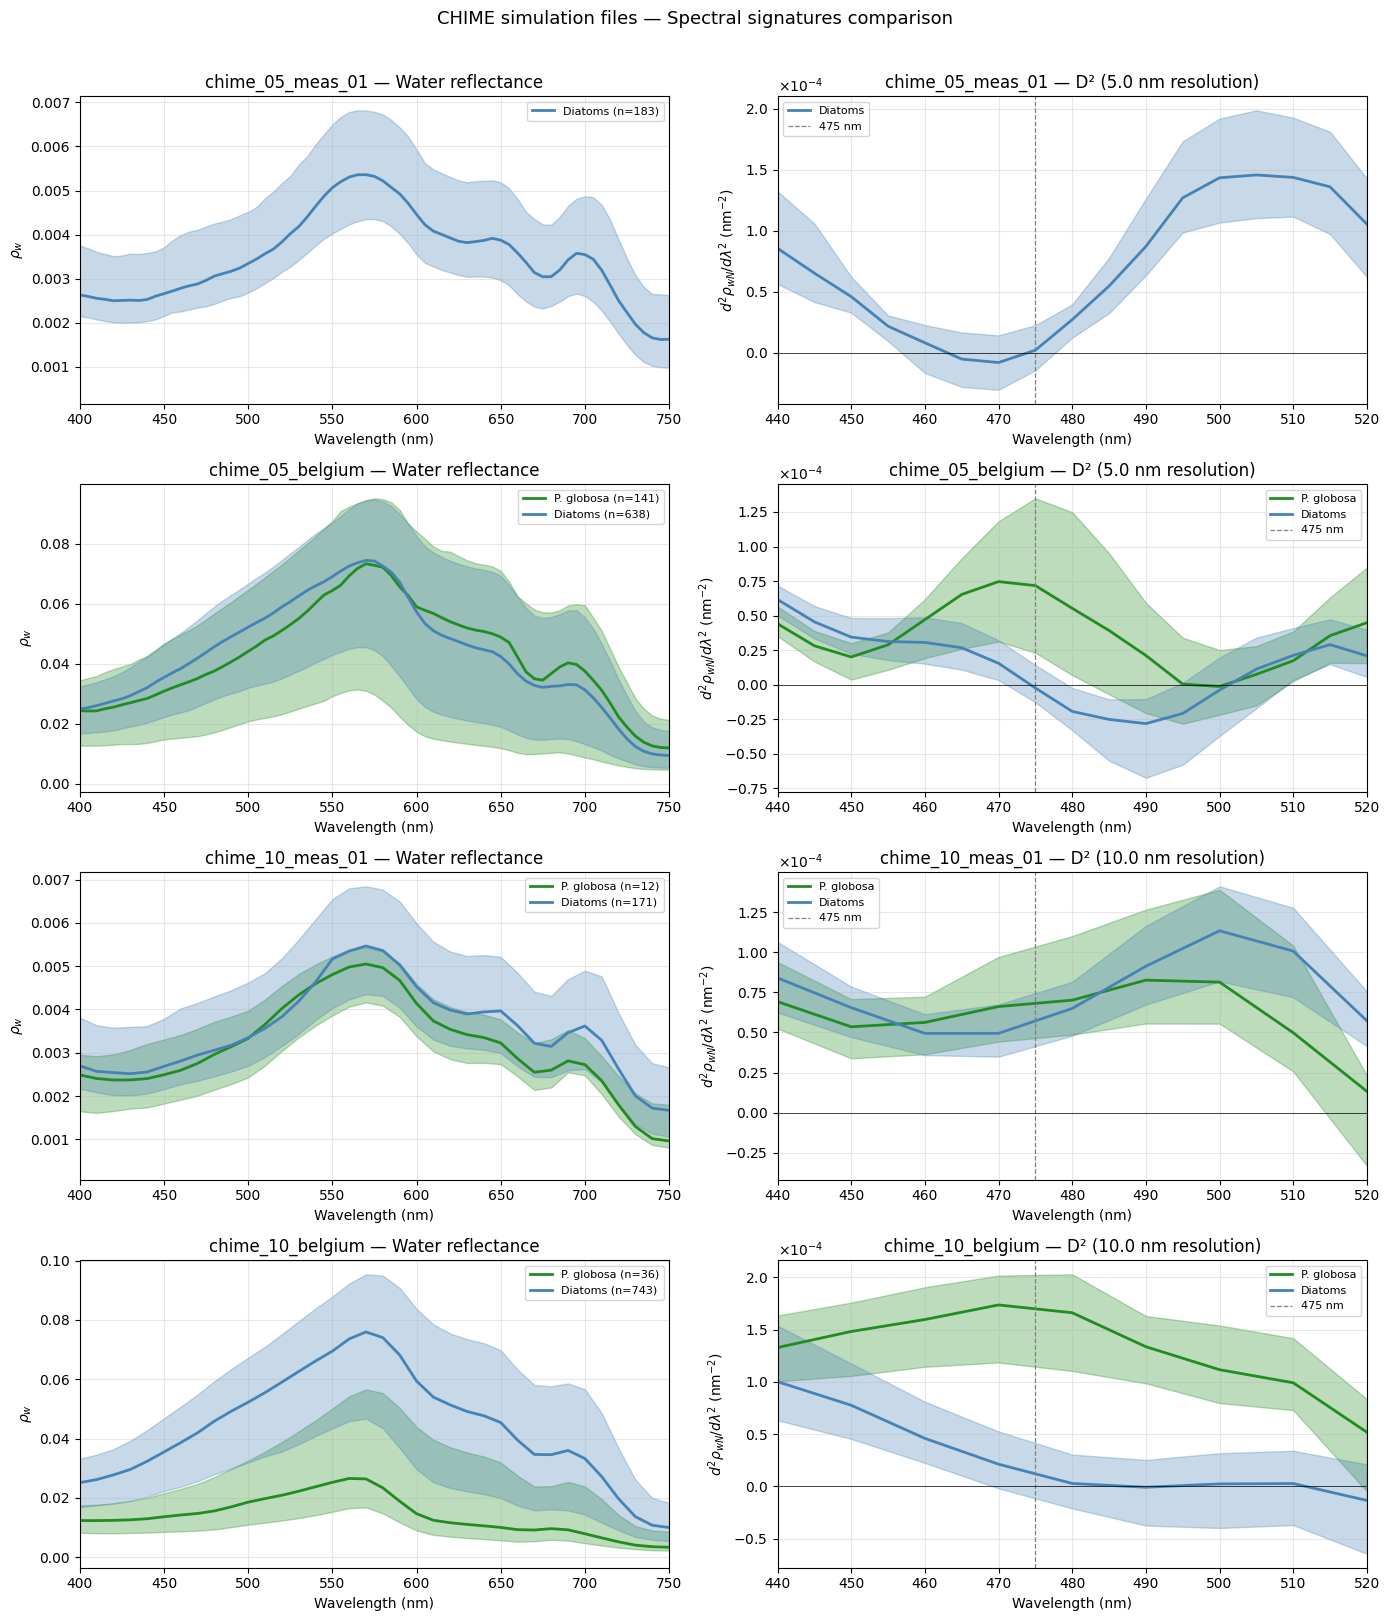

Saved → C:\Users\gvillegas\OneDrive - Institute of Natural Sciences\Projects\REMSEM\aquatime\AQUAPHYTO\figures\figures_chime\fig1_spectral_signatures.png


In [4]:
n_files = len(RESULTS)
fig, axes = plt.subplots(n_files, 2, figsize=(14, 4 * n_files))
if n_files == 1:
    axes = axes[np.newaxis, :]

for row, r in enumerate(RESULTS):
    wl   = r["wl"]
    RHOW = r["RHOW"]
    D2R  = r["D2R"]
    PLUB = r["PLUB"]

    rhow_cols  = list(range(len(wl)))
    wl_mask    = (wl >= 440) & (wl <= 520)
    d2_wl      = wl[wl_mask]

    phaeo_idx  = PLUB == 1
    diatom_idx = PLUB == 0

    # ── Left: ρw ──
    ax = axes[row, 0]
    if phaeo_idx.sum() > 0:
        ph = RHOW[phaeo_idx, :]
        ax.fill_between(wl, np.nanpercentile(ph, 25, axis=0),
                        np.nanpercentile(ph, 75, axis=0), alpha=0.3, color='forestgreen')
        ax.plot(wl, np.nanmedian(ph, axis=0), color='forestgreen', lw=2,
                label=f'P. globosa (n={phaeo_idx.sum()})')
    if diatom_idx.sum() > 0:
        di = RHOW[diatom_idx, :]
        ax.fill_between(wl, np.nanpercentile(di, 25, axis=0),
                        np.nanpercentile(di, 75, axis=0), alpha=0.3, color='steelblue')
        ax.plot(wl, np.nanmedian(di, axis=0), color='steelblue', lw=2,
                label=f'Diatoms (n={diatom_idx.sum()})')
    ax.set(xlabel='Wavelength (nm)', ylabel=r'$\rho_w$',
           title=f'{r["label"]} — Water reflectance', xlim=(400, 750))
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

    # ── Right: D² ──
    ax = axes[row, 1]
    if phaeo_idx.sum() > 0:
        ph_d2 = D2R[phaeo_idx, :][:, wl_mask]
        ax.fill_between(d2_wl, np.nanpercentile(ph_d2, 25, axis=0),
                        np.nanpercentile(ph_d2, 75, axis=0), alpha=0.3, color='forestgreen')
        ax.plot(d2_wl, np.nanmedian(ph_d2, axis=0), color='forestgreen', lw=2,
                label='P. globosa')
    if diatom_idx.sum() > 0:
        di_d2 = D2R[diatom_idx, :][:, wl_mask]
        ax.fill_between(d2_wl, np.nanpercentile(di_d2, 25, axis=0),
                        np.nanpercentile(di_d2, 75, axis=0), alpha=0.3, color='steelblue')
        ax.plot(d2_wl, np.nanmedian(di_d2, axis=0), color='steelblue', lw=2,
                label='Diatoms')
    ax.axvline(475, color='grey', linestyle='--', lw=0.9, label='475 nm')
    ax.axhline(0, color='k', lw=0.5)
    ax.set(xlabel='Wavelength (nm)',
           ylabel=r'$d^2\rho_{wN}/d\lambda^2$ (nm$^{-2}$)',
           title=f'{r["label"]} — D² ({r["delta"]} nm resolution)',
           xlim=(440, 520))
    ax.yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
    ax.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.suptitle('CHIME simulation files — Spectral signatures comparison', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig1_spectral_signatures.png', dpi=200, bbox_inches='tight')
plt.show()
print(f"Saved → {FIG_DIR / 'fig1_spectral_signatures.png'}")

## 4 — Figure 2: MALH distributions (all files)

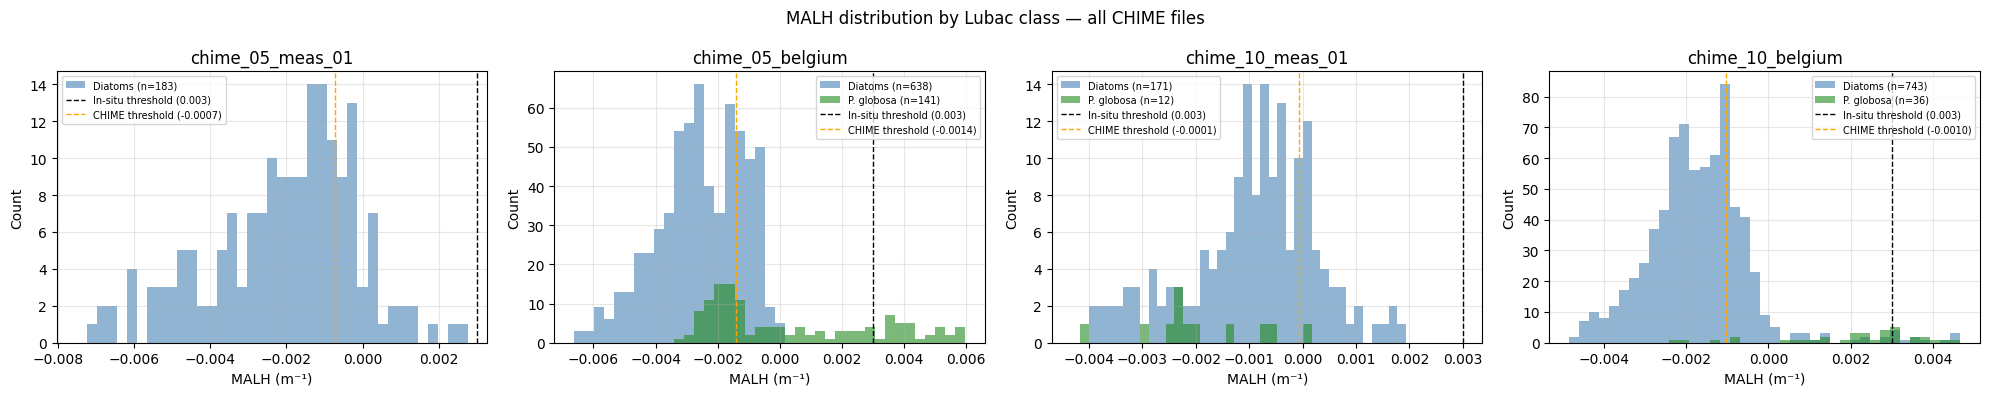

Saved → C:\Users\gvillegas\OneDrive - Institute of Natural Sciences\Projects\REMSEM\aquatime\AQUAPHYTO\figures\figures_chime\fig2_malh_distributions.png


In [5]:
fig, axes = plt.subplots(1, n_files, figsize=(5 * n_files, 4), sharey=False)
if n_files == 1:
    axes = [axes]

for ax, r in zip(axes, RESULTS):
    malh_d = r["MALH"][r["PLUB"] == 0]
    malh_p = r["MALH"][r["PLUB"] == 1]

    # Clip extreme outliers for display
    p1, p99 = np.nanpercentile(r["MALH"], [1, 99])
    bins = np.linspace(p1, p99, 40)

    ax.hist(malh_d, bins=bins, alpha=0.6, color='steelblue',
            label=f'Diatoms (n={len(malh_d)})')
    if len(malh_p) > 0:
        ax.hist(malh_p, bins=bins, alpha=0.6, color='forestgreen',
                label=f'P. globosa (n={len(malh_p)})')

    ax.axvline(INSITU_REF["malh_threshold"], color='k',
               linestyle='--', lw=1.0, label='In-situ threshold (0.003)')

    if not np.isnan(r["candidate_thr"]):
        ax.axvline(r["candidate_thr"], color='orange',
                   linestyle='--', lw=1.0,
                   label=f'CHIME threshold ({r["candidate_thr"]:.4f})')

    ax.set(xlabel='MALH (m⁻¹)', ylabel='Count', title=r["label"])
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)

plt.suptitle('MALH distribution by Lubac class — all CHIME files', fontsize=12)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig2_malh_distributions.png', dpi=200, bbox_inches='tight')
plt.show()
print(f"Saved → {FIG_DIR / 'fig2_malh_distributions.png'}")

## 5 — Figure 3: D² at 475 nm scatter (all files)

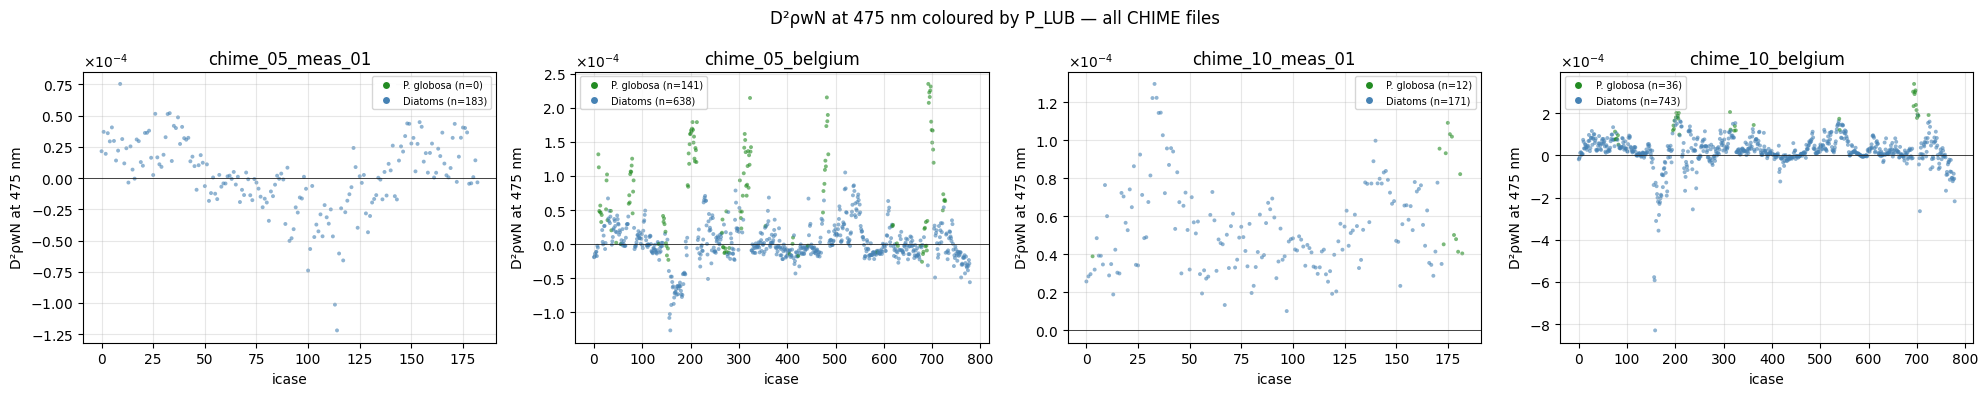

Saved → C:\Users\gvillegas\OneDrive - Institute of Natural Sciences\Projects\REMSEM\aquatime\AQUAPHYTO\figures\figures_chime\fig3_d2_475nm_scatter.png


In [6]:
fig, axes = plt.subplots(1, n_files, figsize=(5 * n_files, 4), sharey=False)
if n_files == 1:
    axes = [axes]

for ax, r in zip(axes, RESULTS):
    wl   = r["wl"]
    idx  = int(np.argmin(np.abs(wl - 475.0)))
    d2_475 = r["D2R"][:, idx]
    colors = ['forestgreen' if p else 'steelblue' for p in r["PLUB"]]

    ax.scatter(range(r["N"]), d2_475, c=colors, s=8, alpha=0.6, linewidths=0)
    ax.axhline(0, color='k', lw=0.5)
    ax.set(xlabel='icase', ylabel='D²ρwN at 475 nm',
           title=r["label"])
    ax.yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
    ax.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
    ax.grid(alpha=0.3)

    # Custom legend
    from matplotlib.lines import Line2D
    ax.legend(handles=[
        Line2D([0],[0], marker='o', color='w', markerfacecolor='forestgreen',
               markersize=6, label=f'P. globosa (n={r["n_phaeo"]})',),
        Line2D([0],[0], marker='o', color='w', markerfacecolor='steelblue',
               markersize=6, label=f'Diatoms (n={r["n_diatom"]})',),
    ], fontsize=7)

plt.suptitle('D²ρwN at 475 nm coloured by P_LUB — all CHIME files', fontsize=12)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig3_d2_475nm_scatter.png', dpi=200, bbox_inches='tight')
plt.show()
print(f"Saved → {FIG_DIR / 'fig3_d2_475nm_scatter.png'}")

## 6 — Figure 4: In-situ vs CHIME algorithm performance summary

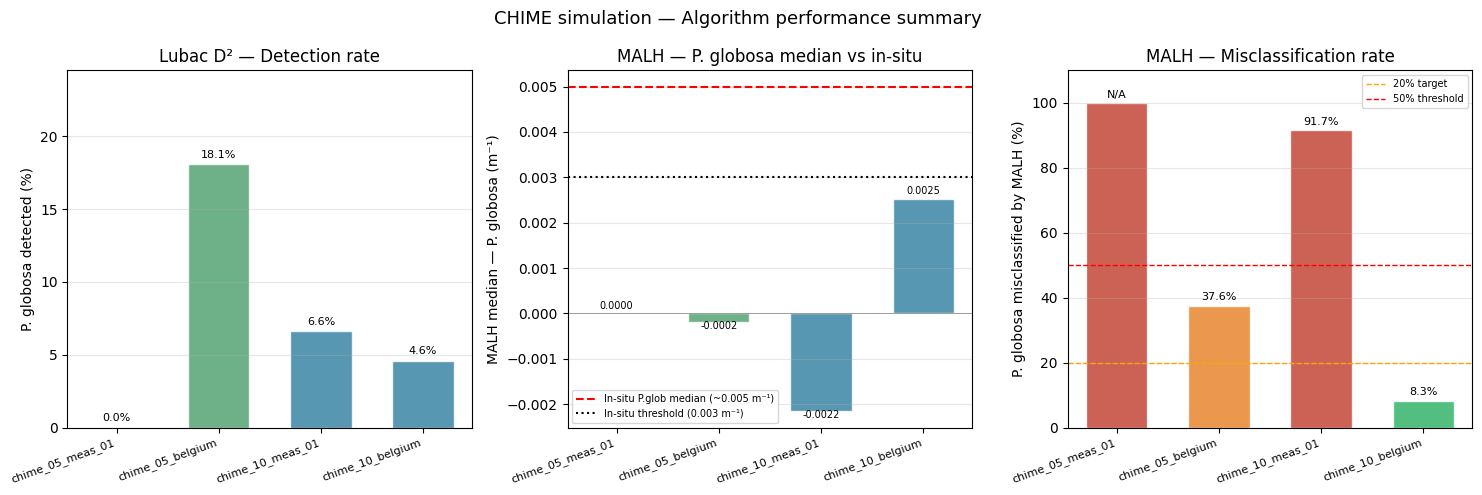

Saved → C:\Users\gvillegas\OneDrive - Institute of Natural Sciences\Projects\REMSEM\aquatime\AQUAPHYTO\figures\figures_chime\fig4_algorithm_performance.png


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

labels      = [r["label"] for r in RESULTS]
pct_phaeo   = [r["pct_phaeo"] for r in RESULTS]
malh_p_med  = [r["malh_phaeo_median"] if not np.isnan(r["malh_phaeo_median"]) else 0
               for r in RESULTS]
misclass    = [r["misclass_pct"] if not np.isnan(r["misclass_pct"]) else 100
               for r in RESULTS]
colors_bar  = ['#4a9e6b' if '05' in l else '#2e7d9e' for l in labels]

x = np.arange(len(labels))
w = 0.6

# ── Panel 1: P. globosa detection rate ───────────────────────────────────────
ax = axes[0]
bars = ax.bar(x, pct_phaeo, width=w, color=colors_bar, alpha=0.8, edgecolor='white')
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=20, ha='right', fontsize=8)
ax.set_ylabel('P. globosa detected (%)')
ax.set_title('Lubac D² — Detection rate')
ax.set_ylim(0, max(pct_phaeo) * 1.3 + 1)
for bar, val in zip(bars, pct_phaeo):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=8)
ax.grid(axis='y', alpha=0.3)

# ── Panel 2: MALH P. globosa median vs in-situ reference ─────────────────────
ax = axes[1]
bars = ax.bar(x, malh_p_med, width=w, color=colors_bar, alpha=0.8, edgecolor='white')
ax.axhline(INSITU_REF["malh_phaeo_median"], color='red', linestyle='--',
           lw=1.5, label=f'In-situ P.glob median (~{INSITU_REF["malh_phaeo_median"]} m⁻¹)')
ax.axhline(INSITU_REF["malh_threshold"], color='k', linestyle=':',
           lw=1.5, label=f'In-situ threshold ({INSITU_REF["malh_threshold"]} m⁻¹)')
ax.axhline(0, color='grey', lw=0.5)
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=20, ha='right', fontsize=8)
ax.set_ylabel('MALH median — P. globosa (m⁻¹)')
ax.set_title('MALH — P. globosa median vs in-situ')
ax.legend(fontsize=7)
ax.grid(axis='y', alpha=0.3)
for bar, val in zip(bars, malh_p_med):
    ypos = bar.get_height() + 0.00005 if val >= 0 else bar.get_height() - 0.0002
    ax.text(bar.get_x() + bar.get_width()/2, ypos,
            f'{val:.4f}', ha='center', va='bottom', fontsize=7)

# ── Panel 3: MALH misclassification rate ─────────────────────────────────────
ax = axes[2]
bar_colors_mc = ['#c0392b' if m > 50 else '#e67e22' if m > 20 else '#27ae60'
                 for m in misclass]
bars = ax.bar(x, misclass, width=w, color=bar_colors_mc, alpha=0.8, edgecolor='white')
ax.axhline(20, color='orange', linestyle='--', lw=1.0, label='20% target')
ax.axhline(50, color='red',    linestyle='--', lw=1.0, label='50% threshold')
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=20, ha='right', fontsize=8)
ax.set_ylabel('P. globosa misclassified by MALH (%)')
ax.set_title('MALH — Misclassification rate')
ax.set_ylim(0, 110)
ax.legend(fontsize=7)
ax.grid(axis='y', alpha=0.3)
for bar, val, lbl in zip(bars, misclass, labels):
    label_txt = f'{val:.1f}%' if val < 100 else 'N/A'
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            label_txt, ha='center', va='bottom', fontsize=8)

plt.suptitle('CHIME simulation — Algorithm performance summary', fontsize=13)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig4_algorithm_performance.png', dpi=200, bbox_inches='tight')
plt.show()
print(f"Saved → {FIG_DIR / 'fig4_algorithm_performance.png'}")

## 7 — Figure 5: Resolution effect — 5 nm vs 10 nm direct comparison

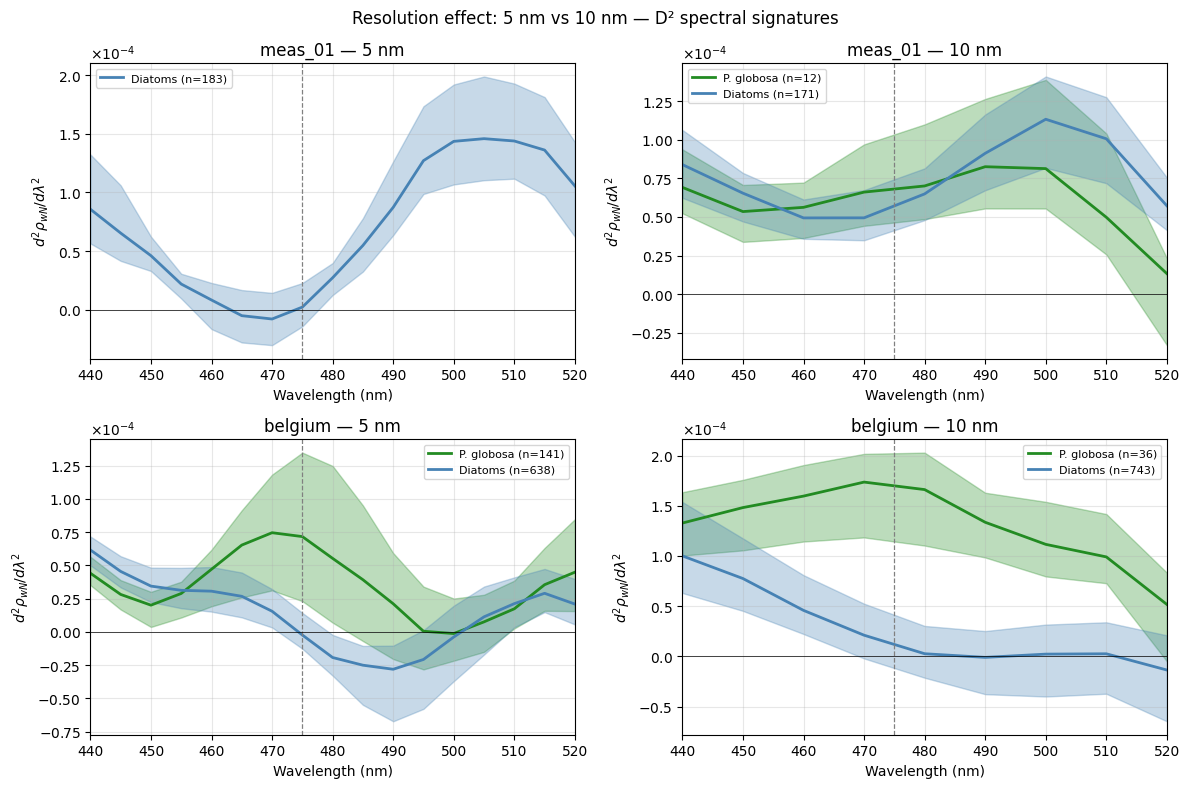

Saved → C:\Users\gvillegas\OneDrive - Institute of Natural Sciences\Projects\REMSEM\aquatime\AQUAPHYTO\figures\figures_chime\fig5_resolution_comparison.png


In [8]:
# Group by dataset name (belgium / meas_01) and compare 5 vs 10 nm
# Assumes FILES contains paired 05/10 entries for same dataset

pairs = {}
for r in RESULTS:
    # Extract dataset name by removing resolution prefix
    key = r["label"].replace("chime_05_", "").replace("chime_10_", "")
    if key not in pairs:
        pairs[key] = {}
    res_key = "5nm" if r["delta"] == 5.0 else "10nm"
    pairs[key][res_key] = r

valid_pairs = {k: v for k, v in pairs.items()
               if "5nm" in v and "10nm" in v}

if not valid_pairs:
    print("No matched 5nm/10nm pairs found — skipping resolution comparison.")
else:
    fig, axes = plt.subplots(len(valid_pairs), 2,
                             figsize=(12, 4 * len(valid_pairs)))
    if len(valid_pairs) == 1:
        axes = axes[np.newaxis, :]

    for row, (dataset, pair) in enumerate(valid_pairs.items()):
        for col, (res_label, r) in enumerate([("5 nm", pair["5nm"]),
                                               ("10 nm", pair["10nm"])]):
            ax   = axes[row, col]
            wl   = r["wl"]
            wl_mask = (wl >= 440) & (wl <= 520)
            d2_wl   = wl[wl_mask]

            phaeo_idx  = r["PLUB"] == 1
            diatom_idx = r["PLUB"] == 0

            if phaeo_idx.sum() > 0:
                ph = r["D2R"][phaeo_idx, :][:, wl_mask]
                ax.fill_between(d2_wl,
                                np.nanpercentile(ph, 25, axis=0),
                                np.nanpercentile(ph, 75, axis=0),
                                alpha=0.3, color='forestgreen')
                ax.plot(d2_wl, np.nanmedian(ph, axis=0),
                        color='forestgreen', lw=2,
                        label=f'P. globosa (n={phaeo_idx.sum()})')

            if diatom_idx.sum() > 0:
                di = r["D2R"][diatom_idx, :][:, wl_mask]
                ax.fill_between(d2_wl,
                                np.nanpercentile(di, 25, axis=0),
                                np.nanpercentile(di, 75, axis=0),
                                alpha=0.3, color='steelblue')
                ax.plot(d2_wl, np.nanmedian(di, axis=0),
                        color='steelblue', lw=2,
                        label=f'Diatoms (n={diatom_idx.sum()})')

            ax.axvline(475, color='grey', linestyle='--', lw=0.9)
            ax.axhline(0, color='k', lw=0.5)
            ax.set(xlabel='Wavelength (nm)',
                   ylabel=r'$d^2\rho_{wN}/d\lambda^2$',
                   title=f'{dataset} — {res_label}',
                   xlim=(440, 520))
            ax.yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
            ax.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
            ax.legend(fontsize=8)
            ax.grid(alpha=0.3)

    plt.suptitle('Resolution effect: 5 nm vs 10 nm — D² spectral signatures',
                 fontsize=12)
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'fig5_resolution_comparison.png',
                dpi=200, bbox_inches='tight')
    plt.show()
    print(f"Saved → {FIG_DIR / 'fig5_resolution_comparison.png'}")

## 8 — Print final interpreted report

In [9]:
print("=" * 70)
print("CHIME SIMULATION — ALGORITHM PERFORMANCE REPORT")
print("=" * 70)

print("\n── Lubac D² classifier ──────────────────────────────────────────")
for r in RESULTS:
    status = "✅" if r["pct_phaeo"] >= 10 else ("⚠️" if r["pct_phaeo"] > 0 else "❌")
    print(f"  {status} {r['label']:25s} : {r['n_phaeo']:4d}/{r['N']} "
          f"({r['pct_phaeo']:5.1f}%) P. globosa detected")

print("\n── MALH ─────────────────────────────────────────────────────────")
print(f"  In-situ reference threshold : {INSITU_REF['malh_threshold']:.4f} m⁻¹")
for r in RESULTS:
    if np.isnan(r["malh_phaeo_median"]):
        print(f"  ❌ {r['label']:25s} : no P. globosa detections")
    else:
        mc = r["misclass_pct"]
        status = "✅" if mc < 20 else ("⚠️" if mc < 50 else "❌")
        print(f"  {status} {r['label']:25s} : P.glob median={r['malh_phaeo_median']:+.5f}  "
              f"misclassified={mc:.1f}%  "
              f"suggested threshold={r['candidate_thr']:.5f} m⁻¹")

print("\n── CHL (CRAT) ───────────────────────────────────────────────────")
for r in RESULTS:
    status = "✅" if r["chl_valid"] > 0 else "❌"
    print(f"  {status} {r['label']:25s} : {r['chl_valid']}/{r['N']} valid CHL values")

print("\n── Conclusion ───────────────────────────────────────────────────")
print("  D²  : most transferable — relies on spectral shape, not magnitude")
print("  MALH: requires recalibration — magnitude suppressed in simulated data")
print("  CHL : not applicable — turbid-water shape fails CRAT red-peak check")
print("=" * 70)

CHIME SIMULATION — ALGORITHM PERFORMANCE REPORT

── Lubac D² classifier ──────────────────────────────────────────
  ❌ chime_05_meas_01          :    0/183 (  0.0%) P. globosa detected
  ✅ chime_05_belgium          :  141/779 ( 18.1%) P. globosa detected
  ⚠️ chime_10_meas_01          :   12/183 (  6.6%) P. globosa detected
  ⚠️ chime_10_belgium          :   36/779 (  4.6%) P. globosa detected

── MALH ─────────────────────────────────────────────────────────
  In-situ reference threshold : 0.0030 m⁻¹
  ❌ chime_05_meas_01          : no P. globosa detections
  ⚠️ chime_05_belgium          : P.glob median=-0.00020  misclassified=37.6%  suggested threshold=-0.00142 m⁻¹
  ❌ chime_10_meas_01          : P.glob median=-0.00216  misclassified=91.7%  suggested threshold=-0.00008 m⁻¹
  ✅ chime_10_belgium          : P.glob median=+0.00253  misclassified=8.3%  suggested threshold=-0.00103 m⁻¹

── CHL (CRAT) ───────────────────────────────────────────────────
  ❌ chime_05_meas_01          : 0/183 v